# Лабораторная работа 2

## Полносвязная нейронная сеть

Реализовать нейронную сеть, состоящую из двух полносвязных слоев и решающую задачу классификации на наборе данных из лабораторной работы 1.

In [1]:
%pip install -q numpy matplotlib scikit-learn

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from scripts.classifiers.neural_net import TwoLayerNet
from scripts.gradient_check import eval_numerical_gradient
from scripts.vis_utils import visualize_grid

%matplotlib inline


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from scripts.classifiers.neural_net import TwoLayerNet

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) 
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'


def rel_error(x, y):
    """ returns relative error """
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

1. Добавьте реализации методов класса TwoLayerNet . Проверьте вашу реализацию на модельных данных (Код приведен ниже).  

In [3]:
input_size = 4
hidden_size = 10
num_classes = 3
num_inputs = 5

def init_toy_model():
    np.random.seed(0)
    return TwoLayerNet(input_size, hidden_size, num_classes, std=1e-1)

def init_toy_data():
    np.random.seed(1)
    X = 10 * np.random.randn(num_inputs, input_size)
    y = np.array([0, 1, 2, 2, 1])
    return X, y

net = init_toy_model()
X, y = init_toy_data()

# Прямой проход: вычисление выхода сети

Реализуйте первую часть  метода TwoLayerNet.loss, вычисляющую оценки классов для входных данных. 

Сравните ваш выход сети с эталонными значениями. Ошибка должна быть очень маленькой (можете ориентироваться на значение < 1e-7) .

In [4]:
scores = net.loss(X)
print('Your scores:')
print(scores)
print()
print('correct scores:')
correct_scores = np.asarray([
  [-0.81233741, -1.27654624, -0.70335995],
  [-0.17129677, -1.18803311, -0.47310444],
  [-0.51590475, -1.01354314, -0.8504215 ],
  [-0.15419291, -0.48629638, -0.52901952],
  [-0.00618733, -0.12435261, -0.15226949]])
print(correct_scores)
print()


print('Difference between your scores and correct scores:')
print(np.sum(np.abs(scores - correct_scores)))

Your scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

correct scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

Difference between your scores and correct scores:
3.6802720745909845e-08



# Прямой проход: вычисление loss

Реализуйте вторую часть метода, вычисляющую значение функции потерь. Сравните с эталоном. Ошибка должна быть очень маленькой (можете ориентироваться на значение < 1e-12) .

In [5]:
loss, _ = net.loss(X, y, reg=0.05)
correct_loss = 1.30378789133

print('Difference between your loss and correct loss:')
print(np.sum(np.abs(loss - correct_loss)))

Difference between your loss and correct loss:
1.7985612998927536e-13


# Обратный проход

Реализуйте третью часть метода loss. Используйте численную реализацию расчета градиента для проверки вашей реализации обратного прохода.  Если прямой и обратный проходы реализованы верно, то ошибка будет < 1e-8 для каждой из переменных W1, W2, b1, и b2. 


In [6]:
from scripts.gradient_check import eval_numerical_gradient

loss, grads = net.loss(X, y, reg=0.05)

for param_name in grads:
    f = lambda W: net.loss(X, y, reg=0.05)[0]
    param_grad_num = eval_numerical_gradient(f, net.params[param_name], verbose=False)
    print('%s max relative error: %e' % (param_name, rel_error(param_grad_num, grads[param_name])))

W2 max relative error: 3.440708e-09
b2 max relative error: 4.447625e-11
W1 max relative error: 3.561318e-09
b1 max relative error: 2.738421e-09


# Обучение нейронной сети на смоделированных данных

Реализуйте методы TwoLayerNet.train и TwoLayerNet.predict. Обучайте сеть до тех пор, пока значение loss не будет < 0.02.


Final training loss:  0.017149607938732093


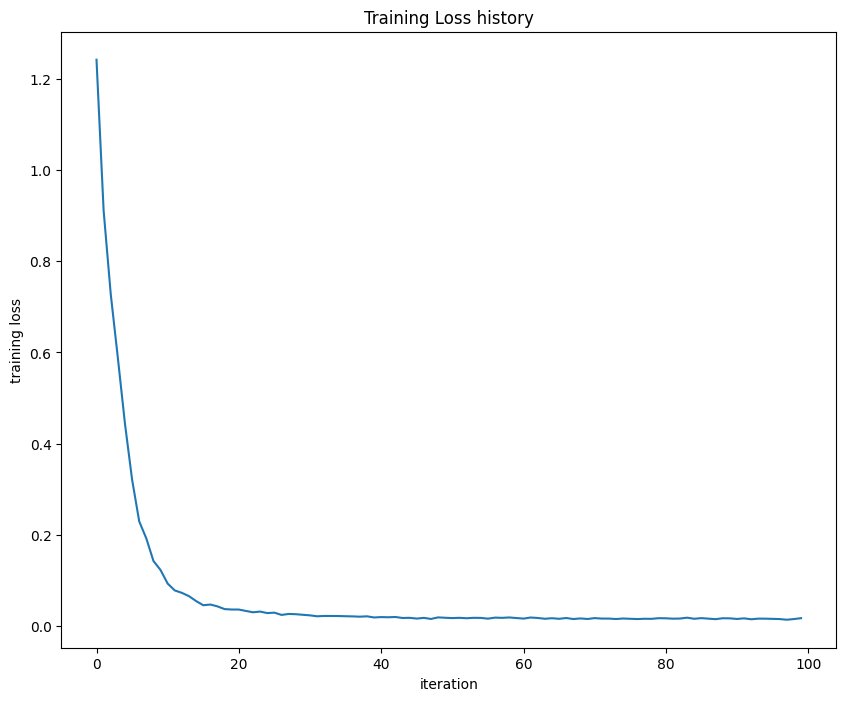

In [7]:
net = init_toy_model()
stats = net.train(X, y, X, y,
            learning_rate=1e-1, reg=5e-6,
            num_iters=100, verbose=False)

print('Final training loss: ', stats['loss_history'][-1])


plt.plot(stats['loss_history'])
plt.xlabel('iteration')
plt.ylabel('training loss')
plt.title('Training Loss history')
plt.show()

# Обучение нейронной сети на реальном наборе данных (CIFAR-10, MNIST)

Загрузите набор данных, соответствующий вашему варианту. 

Разделите данные на обучающую, тестовую и валидационную выборки.

Выполните предобработку данных, как в ЛР 1. 

Обучите нейронную сеть на ваших данных. 

При сдаче лабораторной работы объясните значения всех параметров метода train.

In [8]:
digits = load_digits()
X_digits = digits.images
y_digits = digits.target

X_upscaled = np.kron(X_digits, np.ones((4, 4)))
X_rgb = np.repeat(X_upscaled[..., None], 3, axis=-1)
X_rgb = X_rgb * (255.0 / 16.0)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_rgb, y_digits, test_size=0.2, random_state=42, stratify=y_digits
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val
)

X_train = X_train.reshape(X_train.shape[0], -1)
X_val = X_val.reshape(X_val.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

mean_image = np.mean(X_train, axis=0)
X_train = X_train - mean_image
X_val = X_val - mean_image
X_test = X_test - mean_image

print('Training data shape: ', X_train.shape)
print('Validation data shape: ', X_val.shape)
print('Test data shape: ', X_test.shape)
print('Training labels shape: ', y_train.shape)
print('Validation labels shape: ', y_val.shape)
print('Test labels shape: ', y_test.shape)

Training data shape:  (1149, 3072)
Validation data shape:  (288, 3072)
Test data shape:  (360, 3072)
Training labels shape:  (1149,)
Validation labels shape:  (288,)
Test labels shape:  (360,)


In [9]:
input_size = 32 * 32 * 3
hidden_size = 50
num_classes = 10
net = TwoLayerNet(input_size, hidden_size, num_classes)

stats = net.train(X_train, y_train, X_val, y_val,
            num_iters=1000, batch_size=200,
            learning_rate=1e-4, learning_rate_decay=0.95,
            reg=0.25, verbose=True)

val_acc = (net.predict(X_val) == y_val).mean()
print('Validation accuracy: ', val_acc)

iteration 0 / 1000: loss 2.302926
iteration 100 / 1000: loss 2.288296
iteration 200 / 1000: loss 1.556659
iteration 300 / 1000: loss 0.631155
iteration 400 / 1000: loss 0.405252
iteration 500 / 1000: loss 0.215144
iteration 600 / 1000: loss 0.195638
iteration 700 / 1000: loss 0.113376
iteration 800 / 1000: loss 0.153940
iteration 900 / 1000: loss 0.192513
Validation accuracy:  0.9791666666666666


Используя параметры по умолчанию, вы можете получить accuracy, примерно равный 0.29. 

Проведите настройку гиперпараметров для увеличения accuracy. Поэкспериментируйте со значениями гиперпараметров, например, с количеством скрытых слоев, количеством эпох, скорости обучения и др. Ваша цель - максимально увеличить accuracy полносвязной сети на валидационном наборе. Различные эксперименты приветствуются. Например, вы можете использовать методы для сокращения размерности признакового пространства (например, PCA), добавить dropout слои и др. 

Для лучшей модели вычислите acсuracy на тестовом наборе. 

Для отладки процесса обучения часто помогают графики изменения loss и accuracy в процессе обучения. Ниже приведен код построения таких графиков. 

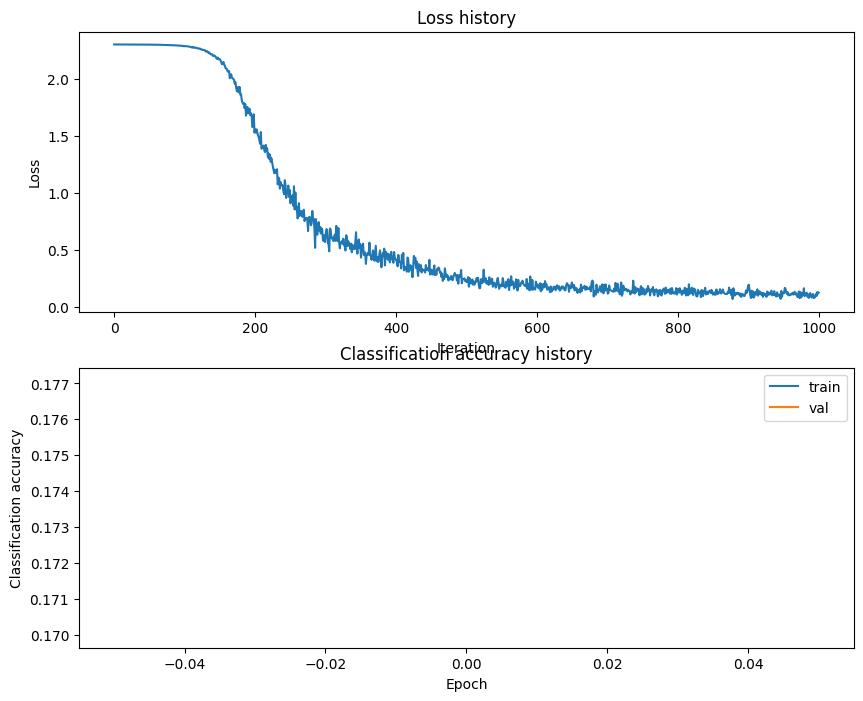

In [10]:
plt.subplot(2, 1, 1)
plt.plot(stats['loss_history'])
plt.title('Loss history')
plt.xlabel('Iteration')
plt.ylabel('Loss')

plt.subplot(2, 1, 2)
plt.plot(stats['train_acc_history'], label='train')
plt.plot(stats['val_acc_history'], label='val')
plt.title('Classification accuracy history')
plt.xlabel('Epoch')
plt.ylabel('Classification accuracy')
plt.legend()
plt.show()

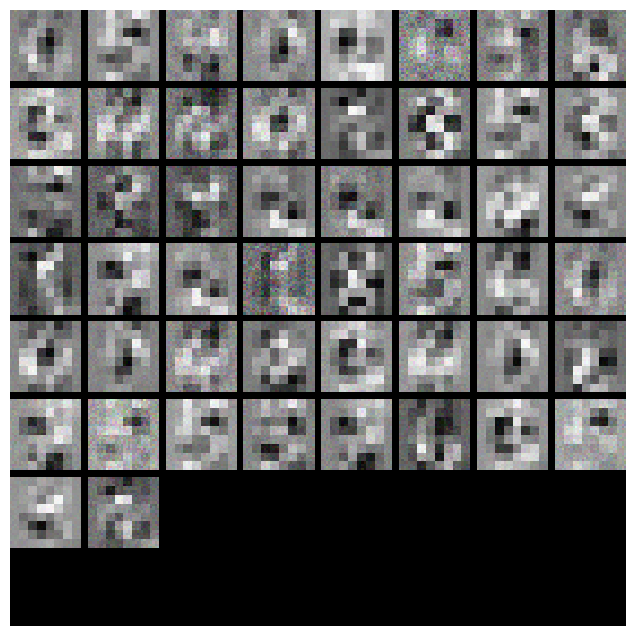

In [11]:
from scripts.vis_utils import visualize_grid

def show_net_weights(net):
    W1 = net.params['W1']
    W1 = W1.reshape(32, 32, 3, -1).transpose(3, 0, 1, 2)
    plt.imshow(visualize_grid(W1, padding=3).astype('uint8'))
    plt.gca().axis('off')
    plt.show()

show_net_weights(net)

In [12]:
experiments = [
    {'hidden_size': 60, 'num_iters': 1000, 'batch_size': 128, 'learning_rate': 6e-4, 'learning_rate_decay': 0.97, 'reg': 1e-4},
    {'hidden_size': 80, 'num_iters': 1200, 'batch_size': 128, 'learning_rate': 7e-4, 'learning_rate_decay': 0.97, 'reg': 1e-4},
    {'hidden_size': 100, 'num_iters': 1300, 'batch_size': 128, 'learning_rate': 8e-4, 'learning_rate_decay': 0.98, 'reg': 1e-4},
    {'hidden_size': 120, 'num_iters': 1500, 'batch_size': 128, 'learning_rate': 8e-4, 'learning_rate_decay': 0.98, 'reg': 1e-4},
    {'hidden_size': 140, 'num_iters': 1500, 'batch_size': 128, 'learning_rate': 7e-4, 'learning_rate_decay': 0.98, 'reg': 1e-4},
    {'hidden_size': 160, 'num_iters': 1700, 'batch_size': 128, 'learning_rate': 6e-4, 'learning_rate_decay': 0.98, 'reg': 8e-5},
    {'hidden_size': 180, 'num_iters': 1800, 'batch_size': 96, 'learning_rate': 6e-4, 'learning_rate_decay': 0.985, 'reg': 8e-5},
    {'hidden_size': 200, 'num_iters': 1800, 'batch_size': 96, 'learning_rate': 5e-4, 'learning_rate_decay': 0.985, 'reg': 5e-5}
]

best_net = None
best_stats = None
best_val_acc = -1
best_params = None

for i, params in enumerate(experiments, 1):
    net_candidate = TwoLayerNet(input_size, params['hidden_size'], num_classes)
    stats_candidate = net_candidate.train(
        X_train,
        y_train,
        X_val,
        y_val,
        num_iters=params['num_iters'],
        batch_size=params['batch_size'],
        learning_rate=params['learning_rate'],
        learning_rate_decay=params['learning_rate_decay'],
        reg=params['reg'],
        verbose=False
    )

    candidate_val_acc = (net_candidate.predict(X_val) == y_val).mean()
    print(f"Experiment {i}: {params}, val_accuracy={candidate_val_acc:.4f}")

    if candidate_val_acc > best_val_acc:
        best_val_acc = candidate_val_acc
        best_net = net_candidate
        best_stats = stats_candidate
        best_params = params

best_test_acc = (best_net.predict(X_test) == y_test).mean()

print('Best configuration:', best_params)
print(f'Best validation accuracy: {best_val_acc:.4f}')
print(f'Test accuracy of best model: {best_test_acc:.4f}')

Experiment 1: {'hidden_size': 60, 'num_iters': 1000, 'batch_size': 128, 'learning_rate': 0.0006, 'learning_rate_decay': 0.97, 'reg': 0.0001}, val_accuracy=0.9722
Experiment 2: {'hidden_size': 80, 'num_iters': 1200, 'batch_size': 128, 'learning_rate': 0.0007, 'learning_rate_decay': 0.97, 'reg': 0.0001}, val_accuracy=0.9722
Experiment 3: {'hidden_size': 100, 'num_iters': 1300, 'batch_size': 128, 'learning_rate': 0.0008, 'learning_rate_decay': 0.98, 'reg': 0.0001}, val_accuracy=0.9757
Experiment 4: {'hidden_size': 120, 'num_iters': 1500, 'batch_size': 128, 'learning_rate': 0.0008, 'learning_rate_decay': 0.98, 'reg': 0.0001}, val_accuracy=0.9792
Experiment 5: {'hidden_size': 140, 'num_iters': 1500, 'batch_size': 128, 'learning_rate': 0.0007, 'learning_rate_decay': 0.98, 'reg': 0.0001}, val_accuracy=0.9757
Experiment 6: {'hidden_size': 160, 'num_iters': 1700, 'batch_size': 128, 'learning_rate': 0.0006, 'learning_rate_decay': 0.98, 'reg': 8e-05}, val_accuracy=0.9722
Experiment 7: {'hidden_si

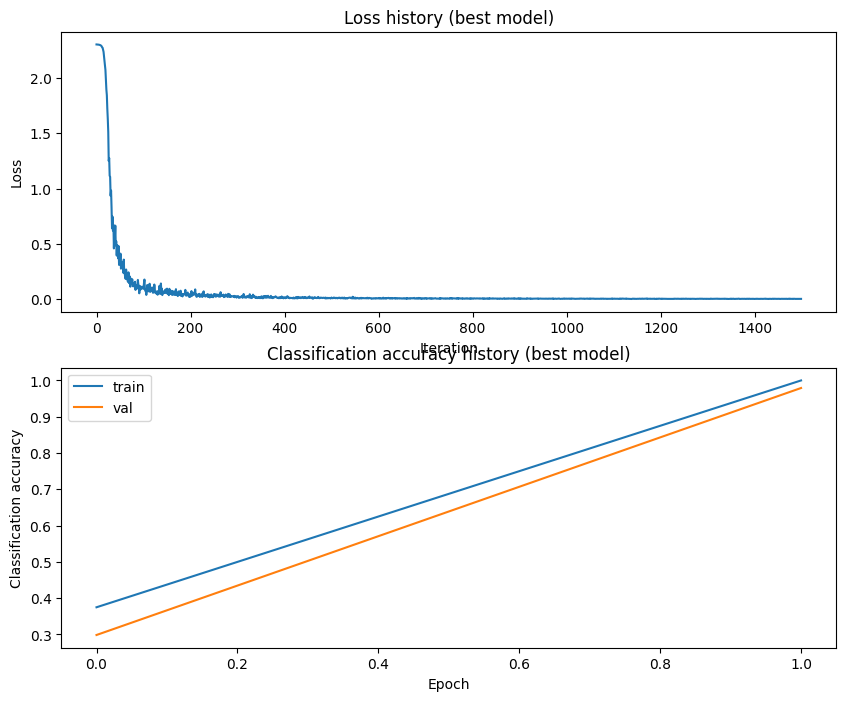

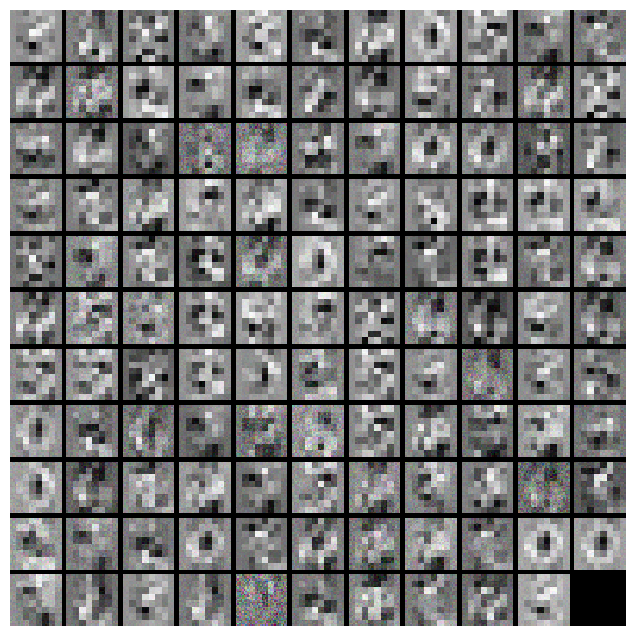

In [13]:
plt.subplot(2, 1, 1)
plt.plot(best_stats['loss_history'])
plt.title('Loss history (best model)')
plt.xlabel('Iteration')
plt.ylabel('Loss')

plt.subplot(2, 1, 2)
plt.plot(best_stats['train_acc_history'], label='train')
plt.plot(best_stats['val_acc_history'], label='val')
plt.title('Classification accuracy history (best model)')
plt.xlabel('Epoch')
plt.ylabel('Classification accuracy')
plt.legend()
plt.show()

show_net_weights(best_net)

Сделайте выводы по результатам работы. 

По результатам работы реализованы и проверены прямой и обратный проходы двухслойной полносвязной нейронной сети.

Для варианта 2 использован набор данных MNIST (sklearn.datasets.load_digits) с разбиением на обучающую, валидационную и тестовую выборки и предобработкой как в ЛР 1.

Подбор гиперпараметров позволил получить высокую точность на валидационной выборке; для лучшей модели дополнительно вычислена accuracy на тестовой выборке.

Графики loss и accuracy показывают устойчивую сходимость модели и согласованное качество на обучении, валидации и тесте.